In [1]:
import pandas as pd

df = pd.read_csv("ch4_mm_gl.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month   decimal  average  average_unc    trend  trend_unc
date                                                                       
1983-07-01  1983      7  1983.542  1626.05         2.39  1635.18       1.46
1983-08-01  1983      8  1983.625  1628.02         2.93  1635.67       1.39
1983-09-01  1983      9  1983.708  1638.42         2.20  1636.23       1.31
1983-10-01  1983     10  1983.792  1644.81         1.47  1636.85       1.23
1983-11-01  1983     11  1983.875  1642.60         0.82  1637.55       1.15


In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1983-07-01 00:00:00 to 2024-04-01 00:00:00
Number of observations: 490

Holdout data:
2024-05-01 00:00:00 to 2026-04-01 00:00:00
Number of observations: 24


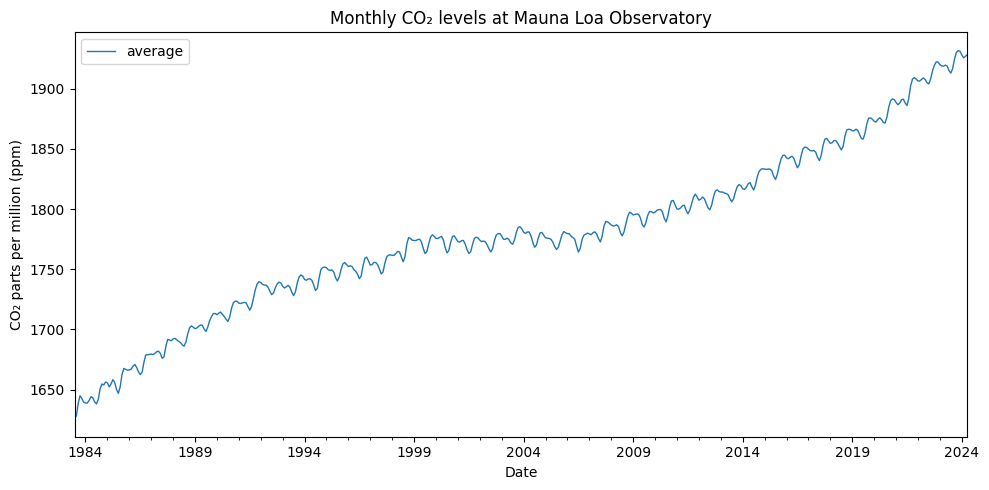

In [3]:
# Step 1: PLot the raw Series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

In [4]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 0.2036
p-value       : 0.9725
Lags Used     : 13
Observations  : 476

Critical Values:
   1%: -3.4442
   5%: -2.8676
   10%: -2.5700


KPSS Test
----------------
KPSS Statistic : 3.5595
p-value        : 0.0100
Lags Used      : 12

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2154/4093660534.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


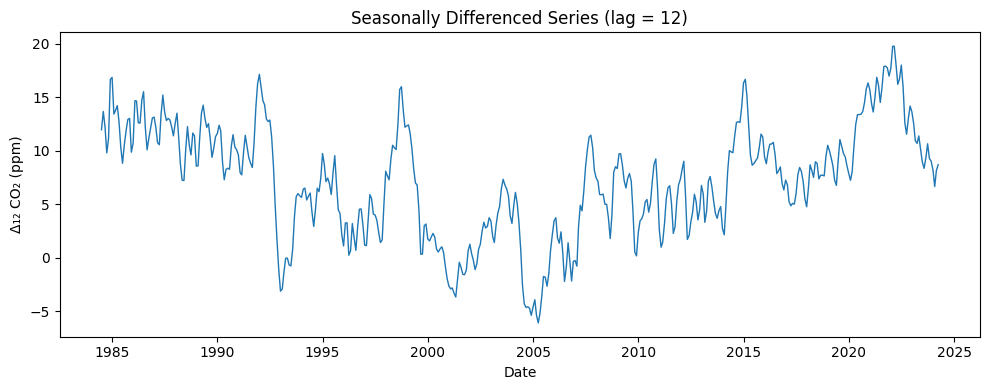

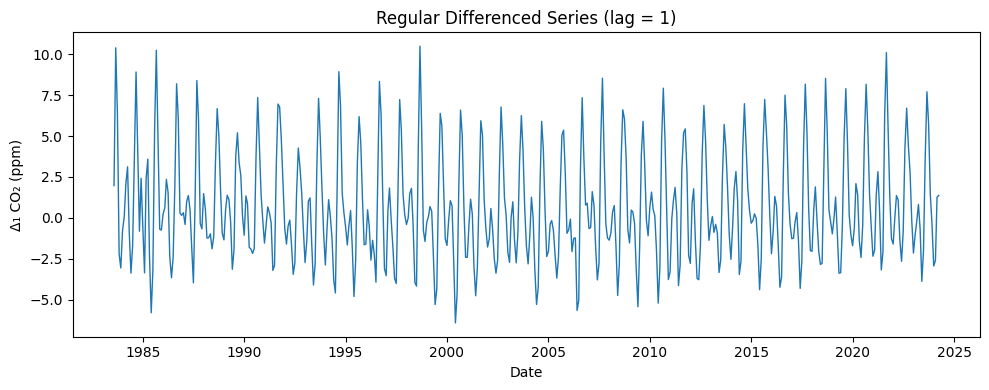

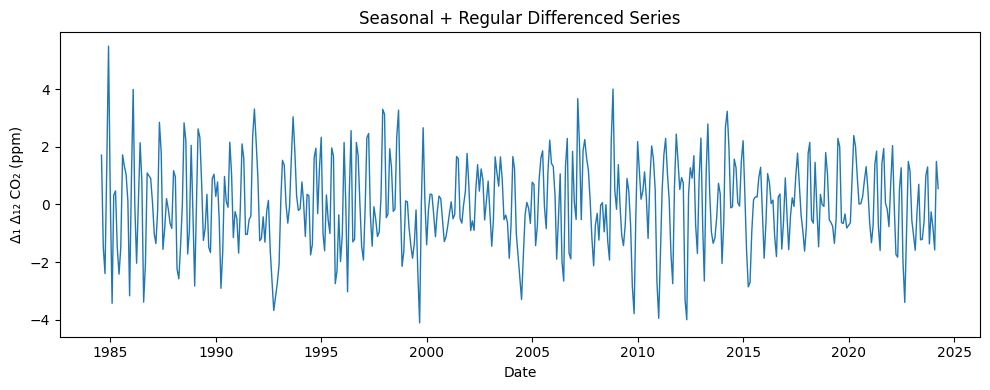

In [5]:
import matplotlib.pyplot as plt

# --- Seasonal differencing (lag 12) ---
train["diff_seasonal"] = train["average"].diff(12)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_seasonal"], linewidth=1)
plt.title("Seasonally Differenced Series (lag = 12)")
plt.xlabel("Date")
plt.ylabel("Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Regular Differenced Series (lag = 1)")
plt.xlabel("Date")
plt.ylabel("Δ₁ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Seasonal + Regular Differenced Series")
plt.xlabel("Date")
plt.ylabel("Δ₁ Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()


In [6]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -7.3127
p-value       : 0.0000
Lags Used     : 13
Observations  : 463

Critical Values:
   1%: -3.4446
   5%: -2.8678
   10%: -2.5701


KPSS Test
----------------
KPSS Statistic : 0.0377
p-value        : 0.1000
Lags Used      : 12

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2154/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')
